# SBI for Binary Stars in Star Clusters

This notebook demonstrates how to use `ElisaBinary` to infer individual
binary-star parameters — primary mass *M1* and mass ratio *q* — from
Gaia photometry of star-cluster members using
**Simulation-Based Inference (SBI)**.

## Workflow

1. **Setup** — load MIST stellar tracks and build a photometric noise model
2. **Define your prior** — any distribution with `.sample()` and `.log_prob()`
3. **Train the posterior** — run forward simulations and train SNPE
4. **Infer on real data** — query the posterior for each observed star
5. **Visualise results** — CMD coloured by *q*, corner plots

> **Note:** training takes a few minutes (~100 000 simulations by default).
> Once trained, the posterior can be saved and reloaded instantly.


In [1]:
import os

import corner
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.distributions import Beta, Independent, Uniform
from torch.distributions.transforms import AffineTransform
from torch.distributions.transformed_distribution import TransformedDistribution

from elisa.sbi import ElisaBinary
from elisa.query.data import ElisaQuery

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


---
## 1. Setup

Instantiate `ElisaBinary`, load the MIST isochrone tracks, and build a
photometric-error model calibrated to your cluster.

In [2]:
elisa = ElisaBinary()
elisa.set_tracks()   # downloads / caches MIST tracks on first run

### 1.1 Load cluster photometry

The DataFrame (or CSV) must contain:

| Column | Description |
|--------|-------------|
| `Gmag` / `phot_g_mean_mag` | Gaia *G* magnitude |
| `BPmag` / `phot_bp_mean_mag` | Gaia *BP* magnitude |
| `RPmag` / `phot_rp_mean_mag` | Gaia *RP* magnitude |
| `e_Gmag`, `e_BPmag`, `e_RPmag` | Photometric errors (for the noise model) |
| `PlxCorr` / `parallax` | Parallax in mas |

We use the Pleiades as an example — swap `CLUSTER` for any cluster in
the Alfonso+24 catalogue.

In [9]:
CLUSTER = "Melotte_22"   # Pleiades

# query = ElisaQuery()
# _, df_members = query.load_catalog("alfonso-2024", load_members=True)

# source_ids = df_members[df_members["Cluster"] == CLUSTER]["GaiaDR3"].values
# print(f"{CLUSTER}: {len(source_ids)} members")

# df_gaia = query.gaia_source_id(source_id=source_ids)
# print(f"Gaia query returned {len(df_gaia)} rows")
df_gaia = pd.read_csv(f"/Users/steven/Documents/uniandesProject/data_binary/NGC2547.csv")
df_gaia

,Source,M1_median,M1_err_lower,M1_err_upper,q_median,q_err_lower,q_err_upper,FeH_median,FeH_err_lower,FeH_err_upper,...,e_Gmag,BPmag,e_BPmag,RPmag,e_RPmag,BP_RP,rel_Gmag_error,rel_BPmag_error,rel_RPmag_error,isBinary
0,5514534293479431296,0.434960,0.044086,0.037617,0.496061,0.211647,0.225117,0.273359,0.050032,0.056007,...,0.003068,18.360975,0.013808,15.735456,0.005052,2.625519,0.018139,0.075203,0.032106,False
1,5514534426617112960,1.586654,0.066568,0.014178,0.377080,0.183880,0.194510,0.080591,0.148268,0.046464,...,0.002769,10.795831,0.002843,10.403759,0.003793,0.392072,0.025983,0.026334,0.036458,False
2,5514534460977212032,0.323067,0.044063,0.020583,0.324429,0.149992,0.174928,0.242923,0.077334,0.050020,...,0.003217,19.413977,0.051412,16.559654,0.009856,2.854323,0.018069,0.264820,0.059518,False
3,5513476833870265984,0.268687,0.049762,0.019947,0.351860,0.173227,0.193832,0.219680,0.068696,0.052796,...,0.003285,20.007812,0.052784,16.979406,0.009991,3.028406,0.018008,0.263817,0.058842,False
4,5514273017726602240,0.218752,0.009542,0.010520,0.272084,0.133733,0.143216,-0.080282,0.055663,0.058834,...,0.003315,19.336230,0.046256,16.910593,0.010541,2.425637,0.018278,0.239219,0.062334,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,5513474325609186304,0.277856,0.042905,0.042587,0.393328,0.194323,0.212082,0.174352,0.085604,0.074245,...,0.004017,19.538086,0.041780,16.688927,0.014458,2.849159,0.022428,0.213839,0.086632,False
457,5514265703406789504,0.284921,0.049363,0.031287,0.398167,0.187802,0.252106,0.237499,0.076558,0.052561,...,0.003320,19.796630,0.052807,16.752243,0.009083,3.044387,0.018447,0.266747,0.054220,False
458,5514532025736771712,0.657000,0.060591,0.043411,0.419153,0.174566,0.205052,0.146134,0.109260,0.106357,...,0.003254,16.653454,0.010467,14.686912,0.006185,1.966542,0.020743,0.062852,0.042112,False
459,5514534018604379136,0.181611,0.021444,0.013751,0.375560,0.189680,0.245140,0.204397,0.058295,0.053826,...,0.003751,21.084166,0.101201,17.703780,0.013973,3.380386,0.019698,0.479986,0.078927,False


In [11]:
df_gaia.keys()

Index(['Source', 'M1_median', 'M1_err_lower', 'M1_err_upper', 'q_median',
       'q_err_lower', 'q_err_upper', 'FeH_median', 'FeH_err_lower',
       'FeH_err_upper', 'age_fixed', 'distance_fixed', 'Gmag', 'e_Gmag',
       'BPmag', 'e_BPmag', 'RPmag', 'e_RPmag', 'BP_RP', 'rel_Gmag_error',
       'rel_BPmag_error', 'rel_RPmag_error', 'isBinary'],
      dtype='object')

In [12]:
df_gaia = df_gaia.rename(columns={
    "phot_g_mean_mag":         "Gmag",
    "phot_bp_mean_mag":        "BPmag",
    "phot_rp_mean_mag":        "RPmag",
    "parallax":                "PlxCorr",
    "source_id":               "Source",
    "phot_g_mean_flux_error":  "e_Gmag",
    "phot_bp_mean_flux_error": "e_BPmag",
    "phot_rp_mean_flux_error": "e_RPmag",
})

df = df_gaia.dropna(subset=["Gmag", "e_Gmag", "BPmag", "e_BPmag", "RPmag", "e_RPmag"]).copy()
print(f"Stars with complete photometry: {len(df)}")

Stars with complete photometry: 461


### 1.2 Build the photometric-error model

The noise model is a set of magnitude-dependent splines fitted to
the observed error columns.  The simulator samples from these splines
when adding noise to synthetic photometry.

> **Why this matters:** training on noise-free data but inferring from
> noisy observations introduces systematic bias (all stars appear as
> high-*q* binaries).  Always call `set_error_splines` before training.

In [13]:
#os.makedirs("../data", exist_ok=True)
DATA_PATH = f"/Users/steven/Documents/uniandesProject/data_binary/NGC2547.csv"
#df.to_csv(DATA_PATH, index=False)

elisa.set_error_splines(DATA_PATH)

Building error splines from /Users/steven/Documents/uniandesProject/data_binary/NGC2547.csv (461 stars)


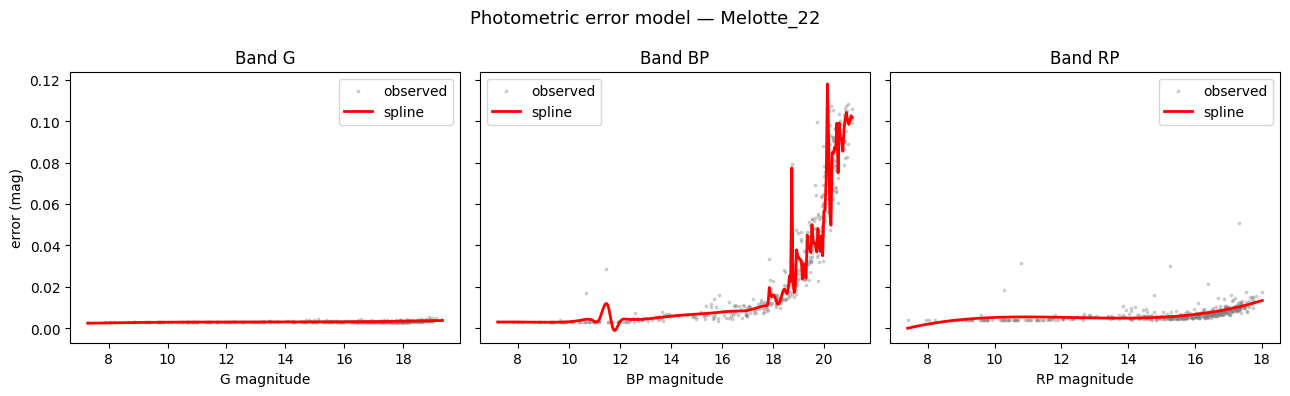

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (band, mag_col, err_col) in zip(
    axes, [("G", "Gmag", "e_Gmag"), ("BP", "BPmag", "e_BPmag"), ("RP", "RPmag", "e_RPmag")]
):
    if err_col not in df.columns:
        ax.set_title(f"{band} — no error column"); continue
    mag_range = np.linspace(df[mag_col].min(), df[mag_col].max(), 300)
    ax.scatter(df[mag_col], df[err_col], s=3, alpha=0.3, color="grey", label="observed")
    ax.plot(mag_range, elisa._error_splines[band](mag_range), "r-", lw=2, label="spline")
    ax.set_xlabel(f"{band} magnitude"); ax.set_title(f"Band {band}"); ax.legend()
axes[0].set_ylabel("error (mag)")
plt.suptitle(f"Photometric error model — {CLUSTER}", fontsize=13)
plt.tight_layout(); plt.show()

---
## 2. Define Your Prior

`ElisaBinary` accepts **any prior** that has `.sample()` and
`.log_prob()` methods — `sbi`'s `BoxUniform`, raw `torch.distributions`,
a fully custom class, or the built-in `StellarPrior` helper.

The prior must cover exactly the parameters you want to infer, **in
this order**: `M1`, `q`, then optionally `age`, `[Fe/H]`, `distance`
(only those not present in `fixed_params`).

### Which parameters to infer?

Pass cluster-level constants through `fixed_params` — they are wired
directly into the simulator and are **not sampled by the prior**.

In [15]:
# Pleiades: ~125 Myr, solar metallicity, 136 pc
fixed_params = {
    "age":      0.125,    # Gyr
    "feh":      0.0,      # [Fe/H]
    "distance": 136.0,    # pc
}
# With all cluster parameters fixed we only infer M1 and q (2-D prior)

### Option A — Uniform prior (simplest)

Use `sbi`'s `BoxUniform` for a flat prior over a rectangular region.

In [16]:
from sbi.utils import BoxUniform

prior_uniform = BoxUniform(
    low=torch.tensor([0.1, 0.0]),   # M1_min, q_min
    high=torch.tensor([5.0, 1.0]),  # M1_max, q_max
)

s = prior_uniform.sample((2_000,)).numpy()
print("BoxUniform sample shape:", s.shape)

BoxUniform sample shape: (2000, 2)


### Option B — Custom Beta prior

Use `torch.distributions` directly to encode astrophysical knowledge:

- **M1**: `Beta(2, 5)` scaled to `[0.1, 5.0]` gives an IMF-like shape
  skewed towards low masses.
- **q**: `Beta(1, 3)` favours single stars (mean *q* ≈ 0.25); use
  `Beta(1, 1)` for uniform.

Wrap the two marginals in `Independent` so `.log_prob()` returns a
scalar per sample.

In [17]:
# M1 ~ Beta(2, 5) mapped to [0.1, 5.0]
M1_dist = TransformedDistribution(
    Beta(torch.tensor([2.0]), torch.tensor([5.0])),
    AffineTransform(loc=torch.tensor([0.1]), scale=torch.tensor([4.9])),
)

# q ~ Beta(1, 3) on [0, 1]  (favours single stars)
q_dist = TransformedDistribution(
    Beta(torch.tensor([1.0]), torch.tensor([3.0])),
    AffineTransform(loc=torch.tensor([0.0]), scale=torch.tensor([1.0])),
)

prior_beta = Independent(
    TransformedDistribution(
        Beta(torch.tensor([2.0, 1.0]), torch.tensor([5.0, 3.0])),
        AffineTransform(loc=torch.tensor([0.1, 0.0]), scale=torch.tensor([4.9, 1.0])),
    ),
    1,
)

s_beta = prior_beta.sample((2_000,)).numpy()
print("Beta prior sample shape:", s_beta.shape)

Beta prior sample shape: (2000, 2)


### Option C — `StellarPrior` convenience class

`StellarPrior` (in `elisa.sbi.priors`) wraps the Beta-prior
construction above into a single class that automatically skips
dimensions for fixed parameters.

In [18]:
from elisa.sbi.priors import StellarPrior

prior_stellar = StellarPrior(
    M1_bounds=(0.1, 5.0),
    q_bounds=(0.0, 1.0),
    M1_alpha=2.0, M1_beta=5.0,   # IMF-like shape
    q_alpha=1.0,  q_beta=4.0,    # uniform on q
    fixed_params=fixed_params,   # age, feh, distance are fixed -> 2-D prior
)

print("StellarPrior mean:    ", prior_stellar.mean)
print("StellarPrior variance:", prior_stellar.variance)

StellarPrior mean:     tensor([1.5039, 0.1979])
StellarPrior variance: tensor([0.6143, 0.0261])


### Compare the three priors

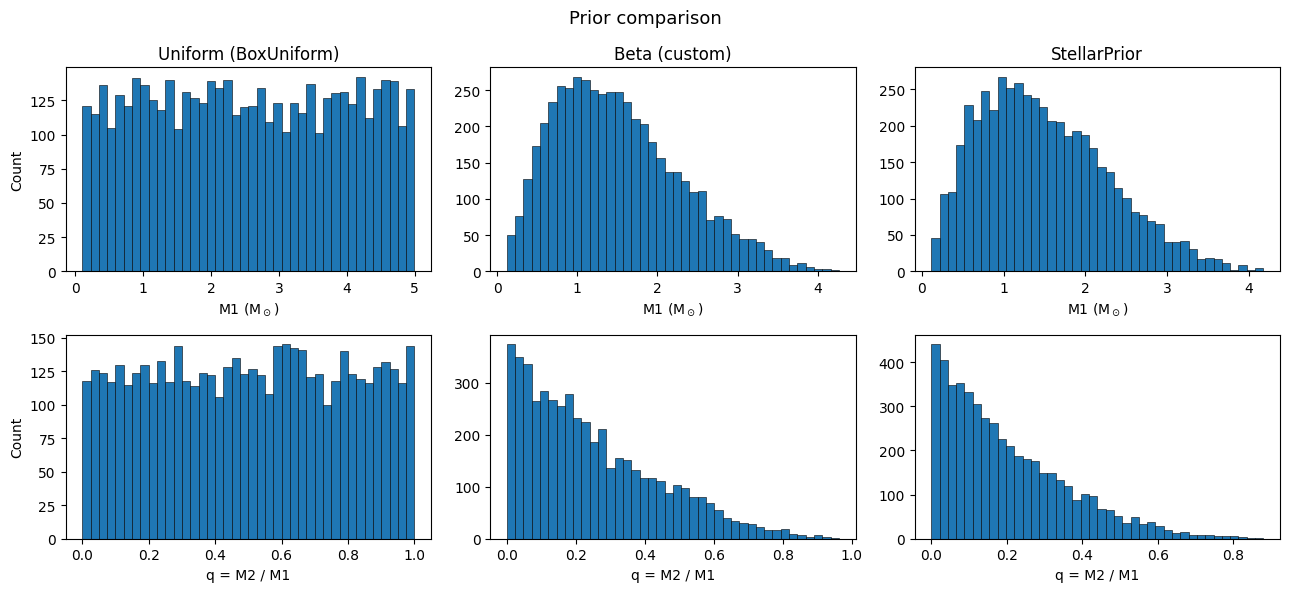

In [19]:
n = 5_000
priors = {
    "Uniform (BoxUniform)": prior_uniform.sample((n,)).numpy(),
    "Beta (custom)": prior_beta.sample((n,)).numpy(),
    "StellarPrior": prior_stellar.sample((n,)).numpy(),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for col, (name, samp) in enumerate(priors.items()):
    axes[0, col].hist(samp[:, 0], bins=40, edgecolor="k", lw=0.4)
    axes[0, col].set_xlabel("M1 (M$_\\odot$)")
    axes[0, col].set_title(name)
    axes[1, col].hist(samp[:, 1], bins=40, edgecolor="k", lw=0.4)
    axes[1, col].set_xlabel("q = M2 / M1")
axes[0, 0].set_ylabel("Count")
axes[1, 0].set_ylabel("Count")
plt.suptitle("Prior comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Pick the prior you want to use for training
prior = prior_stellar   # swap for prior_beta or prior_stellar or prior_uniform

---
## 3. Train the Posterior

`build_posterior` runs the full pipeline:

1. Wraps the simulator with `prepare_for_sbi`
2. Generates `num_simulations` valid (finite) simulations
3. Trains a Sequential Neural Posterior Estimator (SNPE)
4. Returns `(posterior, theta, x)`

> **Tip:** use `num_simulations=10_000` to verify the pipeline first,
> then scale to 100 000 for production quality.

In [21]:
POSTERIOR_PATH = f"../outputs/{CLUSTER}_posterior.pkl"
os.makedirs("../outputs", exist_ok=True)

if os.path.exists(POSTERIOR_PATH):
    print("Loading existing posterior...")
    posterior, (theta, x) = ElisaBinary.load(POSTERIOR_PATH)
    elisa._last_labels = ("M1", "q")   # restore labels after loading
else:
    print("Training posterior...")
    posterior, theta, x = elisa.build_posterior(
        prior=prior,
        fixed_params=fixed_params,
        use_apparent_mags=True,
        num_simulations=50_000,
        sample_with="mcmc",
    )
    elisa.save(posterior, theta, x, POSTERIOR_PATH)

Training posterior...


/opt/homebrew/lib/python3.11/site-packages/sbi/utils/user_input_checks_utils.py:28: UserWarning: No prior bounds were passed, consider passing lower_bound and / or upper_bound if your prior has bounded support.
  self.custom_support = build_support(lower_bound, upper_bound)
Simulating: 100%|██████████| 50000/50000 [01:08<00:00, 724.89it/s]


 Neural network successfully converged after 92 epochs.Saved posterior to ../outputs/Melotte_22_posterior.pkl


/opt/homebrew/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:115: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


### 3.1 Inspect the training simulations

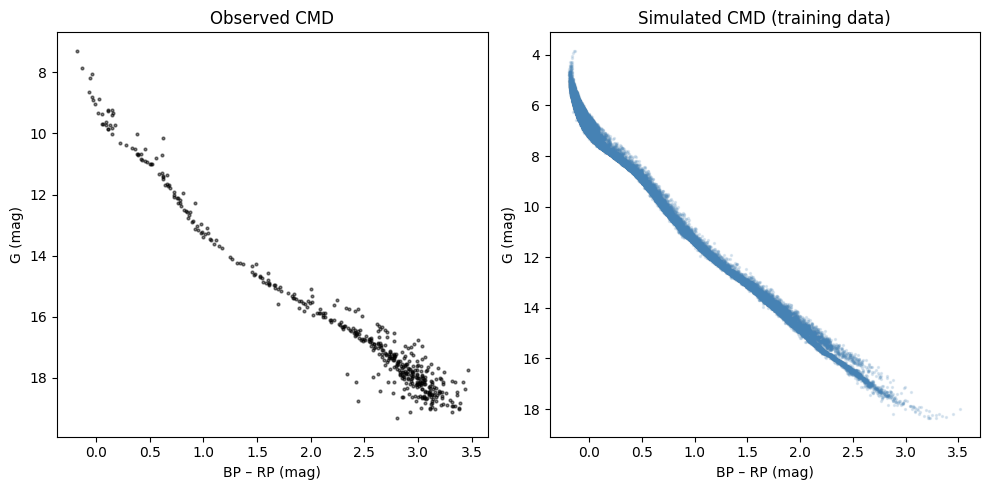

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

bp_rp_obs = df["BPmag"].values - df["RPmag"].values
axes[0].scatter(bp_rp_obs, df["Gmag"].values, s=4, c="k", alpha=0.5)
axes[0].set_xlabel("BP – RP (mag)"); axes[0].set_ylabel("G (mag)")
axes[0].set_title(f"Observed CMD"); axes[0].invert_yaxis()

x_np = x.numpy()
bp_rp_sim = x_np[:, 0] - x_np[:, 1]
axes[1].scatter(bp_rp_sim, x_np[:, 2], s=2, alpha=0.15, c="steelblue")
axes[1].set_xlabel("BP – RP (mag)"); axes[1].set_ylabel("G (mag)")
axes[1].set_title("Simulated CMD (training data)"); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

---
## 4. Infer Parameters for Each Star

`infer()` draws `num_samples` posterior samples per star and returns
medians with 16th / 84th-percentile uncertainties.

In [26]:
RESULTS_PATH = f"../outputs/{CLUSTER}_results.csv"

if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    print("Loaded existing results.")
else:
    results_df = elisa.infer(
        posterior=posterior,
        data=df,
        fixed_params=fixed_params,
        use_apparent_mags=False,
        num_samples=10_000,
        source_col="Source",
    )
    results_df.to_csv(RESULTS_PATH, index=False)

print(f"Results for {len(results_df)} stars")
results_df.head()

KeyError: 'PlxCorr'

---
## 5. Visualise Results

### 5.1 CMD coloured by inferred *q*

In [ ]:
df_res = df.merge(results_df[["Source", "M1_median", "q_median"]], on="Source", how="left")

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(
    df_res["BPmag"] - df_res["RPmag"], df_res["Gmag"],
    c=df_res["q_median"], cmap="plasma", vmin=0, vmax=1, s=10, alpha=0.8,
)
plt.colorbar(sc, ax=ax, label="Inferred  q = M2/M1")
ax.invert_yaxis()
ax.set_xlabel("BP – RP (mag)", fontsize=13)
ax.set_ylabel("G (mag)", fontsize=13)
ax.set_title(f"{CLUSTER} — CMD coloured by mass ratio", fontsize=13)
plt.tight_layout(); plt.show()

### 5.2 Inferred distributions

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results_df["M1_median"].dropna(), bins=40, edgecolor="k", lw=0.5, color="steelblue")
axes[0].set_xlabel("M1 median (M$_\\odot$)", fontsize=12)
axes[0].set_ylabel("Number of stars")
axes[0].set_title("Primary mass distribution")

axes[1].hist(results_df["q_median"].dropna(), bins=40, edgecolor="k", lw=0.5, color="darkorange")
axes[1].set_xlabel("q median", fontsize=12)
axes[1].set_title("Mass-ratio distribution")

plt.suptitle(CLUSTER, fontsize=13)
plt.tight_layout(); plt.show()

bf = (results_df["q_median"] > 0.5).mean()
print(f"Approximate binary fraction (q > 0.5): {bf:.2%}")

### 5.3 Full posterior for a single star

In [ ]:
idx_star   = results_df["q_median"].idxmax()
star_src   = results_df.loc[idx_star, "Source"]
df_star    = df[df["Source"] == star_src].iloc[0]

print(f"Source = {star_src}")
print(f"  M1 = {results_df.loc[idx_star, 'M1_median']:.3f} Msun")
print(f"  q  = {results_df.loc[idx_star, 'q_median']:.3f}")

obs_tensor = torch.tensor(
    [df_star["BPmag"], df_star["RPmag"], df_star["Gmag"], df_star["PlxCorr"]],
    dtype=torch.float32,
)
samples_star = posterior.sample((20_000,), x=obs_tensor).numpy()

fig = corner.corner(
    samples_star,
    labels=[r"$M_1\;(M_\odot)$", r"$q$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_fmt=".3f",
)
fig.suptitle(f"Posterior — Source {star_src}", fontsize=12, y=1.02)
plt.show()

### 5.4 Posterior predictive check

In [ ]:
n_ppc = 500
idx   = np.random.choice(len(samples_star), n_ppc, replace=False)
ppc_bp, ppc_rp, ppc_g = [], [], []

for m1_s, q_s in samples_star[idx]:
    try:
        sim = elisa.binary_color_mag_isochrones(
            m1_s, q_s,
            fixed_params["age"], fixed_params["feh"],
            distance=fixed_params["distance"],
            add_noise=False,
        )
        ppc_bp.append(sim[0]); ppc_rp.append(sim[1]); ppc_g.append(sim[2])
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.array(ppc_bp) - np.array(ppc_rp), ppc_g,
           s=6, alpha=0.3, c="steelblue", label="Posterior predictive")
ax.scatter(df_star["BPmag"] - df_star["RPmag"], df_star["Gmag"],
           s=120, c="red", marker="*", zorder=5, label="Observed")
ax.invert_yaxis()
ax.set_xlabel("BP – RP (mag)"); ax.set_ylabel("G (mag)")
ax.set_title("Posterior predictive check"); ax.legend()
plt.tight_layout(); plt.show()

---
## Tips & Reference

### Inferring cluster parameters jointly

Remove parameters from `fixed_params` and add their ranges to the prior.
The prior must have exactly the right number of dimensions.

```python
# Infer M1, q, age  (fix feh and distance)
fixed_params = {"feh": 0.0, "distance": 136.0}

prior = BoxUniform(
    low=torch.tensor( [0.1, 0.0, 0.05]),   # M1, q, age (Gyr)
    high=torch.tensor([5.0, 1.0, 0.5 ]),
)

posterior, theta, x = elisa.build_posterior(
    prior=prior,
    fixed_params=fixed_params,
    use_apparent_mags=True,
    num_simulations=200_000,   # more sims for higher-D posterior
)
# elisa._last_labels -> ('M1', 'q', 'age')
```

### Saving & reloading

```python
elisa.save(posterior, theta, x, "cluster_posterior.pkl")

posterior, (theta, x) = ElisaBinary.load("cluster_posterior.pkl")
elisa._last_labels = ("M1", "q")   # restore if needed
```

### Inference on a NumPy array

```python
# obs columns must be [BP, RP, G, parallax]
obs = np.column_stack([df["BPmag"], df["RPmag"], df["Gmag"], df["PlxCorr"]])
results = elisa.infer(posterior, data=obs, labels=("M1", "q"), fixed_params=fixed_params)
```

### Troubleshooting

| Issue | Cause | Fix |
|-------|-------|-----|
| High NaN fraction | Mass range too broad | Narrow `M1` bounds to the cluster MS |
| Posterior collapses to prior | Too few simulations | Increase `num_simulations` |
| All stars appear as high-*q* | Missing noise model | Call `set_error_splines` before training |
| MCMC very slow | Default NUTS | Use `sample_with='rejection'` to prototype |
| `RuntimeError` in `infer` | NaN in observations | Drop incomplete rows first |
